In [14]:
!pip install pandas scikit-learn nltk matplotlib seaborn

In [15]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [16]:
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
import pandas as pd

phish_df = pd.read_csv('/Phishing_Email.csv')
spam_df = pd.read_csv('/spam.csv', encoding='latin-1')

print("Phishing dataset shape:", phish_df.shape)
print("Spam dataset shape:", spam_df.shape)


Phishing dataset shape: (18650, 3)
Spam dataset shape: (5572, 5)


In [19]:
print("PHISHING COLUMNS:")
print(phish_df.columns)
print("/nSPAM COLUMNS:")
print(spam_df.columns)

PHISHING COLUMNS:
Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')
/nSPAM COLUMNS:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [20]:
#-------- CLEAN PHISHING DATASET --------
phish_clean = phish_df[['Email Text', 'Email Type']].copy()

# Rename columns
phish_clean.columns = ['text', 'label']

# Convert labels (phishing = 1, others = 0)
phish_clean['label'] = phish_clean['label'].apply(lambda x: 1 if x == 'Phishing Email' else 0)

#-------- CLEAN SPAM DATASET --------
spam_clean = spam_df[['v2', 'v1']].copy()

# Rename columns
spam_clean.columns = ['text', 'label']

# Convert labels (spam = 1, ham = 0)
spam_clean['label'] = spam_clean['label'].apply(lambda x: 1 if str(x).lower() == 'spam' else 0)

#-------- CHECK RESULTS --------
print("Phishing clean shape:", phish_clean.shape)
print("Spam clean shape:", spam_clean.shape)

print("\nPhishing sample:")
print(phish_clean.head())

print("\nSpam sample:")
print(spam_clean.head())


Phishing clean shape: (18650, 2)
Spam clean shape: (5572, 2)

Phishing sample:
                                                text  label
0  re : 6 . 1100 , disc : uniformitarianism , re ...      0
1  the other side of * galicismos * * galicismo *...      0
2  re : equistar deal tickets are you still avail...      0
3  \nHello I am your hot lil horny toy.\n    I am...      1
4  software at incredibly low prices ( 86 % lower...      1

Spam sample:
                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1                      Ok lar... Joking wif u oni...      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0


In [21]:
print(phish_clean['label'].value_counts())

label
0    11322
1     7328
Name: count, dtype: int64


In [22]:
# -------- MERGE DATASETS --------
df = pd.concat([phish_clean, spam_clean], ignore_index=True)

# Shuffle dataset (important)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check result
print("Final dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())


Final dataset shape: (24222, 2)

Class distribution:
label
0    16147
1     8075
Name: count, dtype: int64


In [23]:
# -------- SEPARATE DATASETS --------
phish_only = phish_clean[phish_clean['label'] == 1]
legit_from_phish = phish_clean[phish_clean['label'] == 0]

spam_only = spam_clean[spam_clean['label'] == 1]

# Only use legit from phishing dataset (cleaner)
legit_all = legit_from_phish.copy()

# -------- TARGET DISTRIBUTION --------
TOTAL = 10000

phish_target = int(0.5 * TOTAL)   # 50%
legit_target = int(0.4 * TOTAL)   # 40%
spam_target  = int(0.1 * TOTAL)   # 10%

# -------- ADJUST BASED ON AVAILABLE DATA --------
phish_target = min(phish_target, len(phish_only))
legit_target = min(legit_target, len(legit_all))
spam_target  = min(spam_target, len(spam_only))

# -------- SAMPLE --------
phish_sample = phish_only.sample(n=phish_target, random_state=42)
legit_sample = legit_all.sample(n=legit_target, random_state=42)
spam_sample  = spam_only.sample(n=spam_target, random_state=42)

# -------- MERGE --------
df_final = pd.concat([phish_sample, legit_sample, spam_sample])

# Shuffle
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# -------- CHECK --------
print("Final dataset shape:", df_final.shape)
print("\nFinal class distribution:")
print(df_final['label'].value_counts())

Final dataset shape: (9747, 2)

Final class distribution:
label
1    5747
0    4000
Name: count, dtype: int64


In [24]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to string (extra safety)
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

    df_final['clean_text'] = df_final['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
# Apply cleaning properly (outside function)
df_final['clean_text'] = df_final['text'].apply(clean_text)

print(df_final.columns)

Index(['text', 'label', 'clean_text'], dtype='object')


In [26]:
print(df_final[['text', 'clean_text']].head())

                                                text  \
0  newsweek : u . s visa regulations dreaming of ...   
1  new books : phonology wang jialing and norval ...   
2  decode them all simply so whats on tonight at ...   
3  I'd like to tell you my deepest darkest fantas...   
4  re : file cabinet for mike roberts kevin g moo...   

                                          clean_text  
0  newsweek u visa regulations dreaming new life ...  
1  new books phonology wang jialing norval smith ...  
2  decode simply whats tonight fri apr http twi s...  
3  id like tell deepest darkest fantasies call pm...  
4  file cabinet mike roberts kevin g moore pm mik...  


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialise vectoriser
vectorizer = TfidfVectorizer(max_features=5000)

# Convert text into numerical features
X = vectorizer.fit_transform(df_final['clean_text'])

# Labels
y = df_final['label']

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (9747, 5000)
Labels shape: (9747,)


In [28]:
from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (7797, 5000)
Testing set: (1950, 5000)


In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred = nb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9523076923076923

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.94       824
           1       0.94      0.98      0.96      1126

    accuracy                           0.95      1950
   macro avg       0.96      0.95      0.95      1950
weighted avg       0.95      0.95      0.95      1950



In [30]:
from sklearn.linear_model import LogisticRegression

# Train model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9564102564102565

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.95       824
           1       0.94      0.99      0.96      1126

    accuracy                           0.96      1950
   macro avg       0.96      0.95      0.95      1950
weighted avg       0.96      0.96      0.96      1950



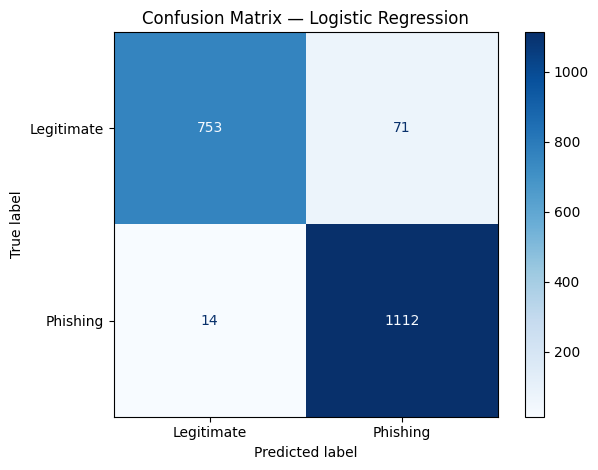

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

In [32]:
print(phish_df['Email Type'].unique())


['Safe Email' 'Phishing Email']


In [33]:
def generate_response(prediction):

    if prediction == 1:
        return (
            "⚠️ Phishing Email Detected\n"
            "Recommended Actions:\n"
            "- Do not click suspicious links\n"
            "- Do not download attachments\n"
            "- Report the email to security personnel\n"
            "- Delete the email immediately"
        )

    else:
        return (
            "✅ Legitimate Email Detected\n"
            "Recommended Actions:\n"
            "- Email appears safe\n"
            "- Review normally\n"
            "- Verify sender if necessary"
        )


def predict_new_email(email_text):

    # Step 1: clean text
    cleaned_email = clean_text(email_text)

    # Step 2: convert using existing TF-IDF model
    email_vector = vectorizer.transform([cleaned_email])

    # Step 3: predict using your final Logistic Regression model
    prediction = lr_model.predict(email_vector)[0]

    # Step 4: generate recommendation
    recommendation = generate_response(prediction)

    print("Original Email:")
    print(email_text)
    print("\nPrediction:", prediction)
    print("\nRecommendation:")
    print(recommendation)

In [34]:
test_email = """
Your account has been suspended.
Click here immediately to verify your bank details.
"""

predict_new_email(test_email)

Original Email:

Your account has been suspended.
Click here immediately to verify your bank details.


Prediction: 1

Recommendation:
⚠️ Phishing Email Detected
Recommended Actions:
- Do not click suspicious links
- Do not download attachments
- Report the email to security personnel
- Delete the email immediately


In [35]:
test_email2 = """
Hi team,
Please find attached the meeting agenda for tomorrow.
Kind regards.
"""

predict_new_email(test_email2)

Original Email:

Hi team,
Please find attached the meeting agenda for tomorrow.
Kind regards.


Prediction: 0

Recommendation:
✅ Legitimate Email Detected
Recommended Actions:
- Email appears safe
- Review normally
- Verify sender if necessary


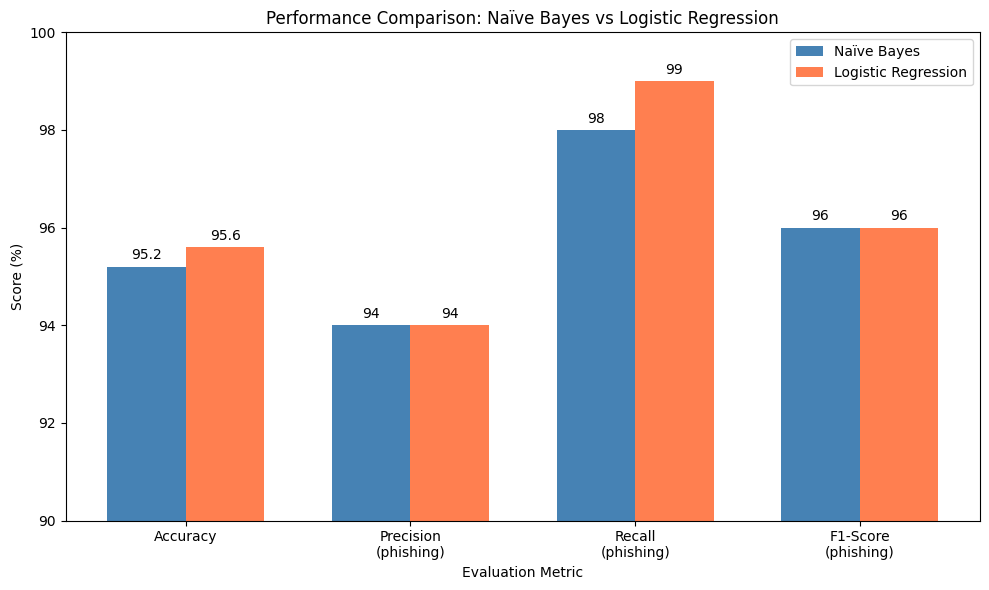

In [36]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Naïve Bayes', 'Logistic Regression']
metrics = ['Accuracy', 'Precision\n(phishing)', 'Recall\n(phishing)', 'F1-Score\n(phishing)']
nb_scores = [95.2, 94, 98, 96]
lr_scores = [95.6, 94, 99, 96]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, nb_scores, width, label='Naïve Bayes', color='steelblue')
bars2 = ax.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='coral')

ax.set_xlabel('Evaluation Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Performance Comparison: Naïve Bayes vs Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(90, 100)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

plt.tight_layout()
plt.show()

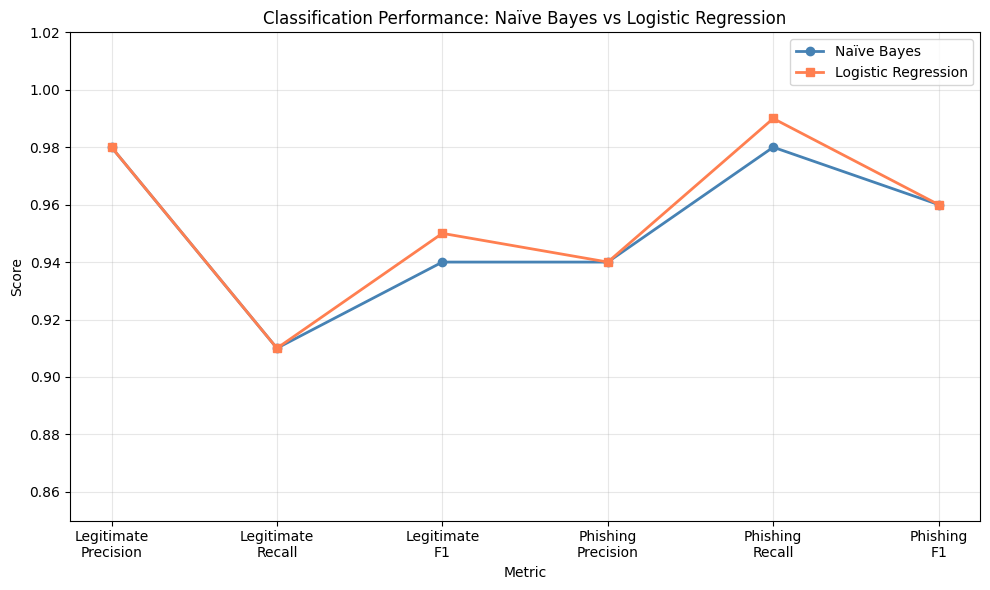

In [37]:
import matplotlib.pyplot as plt

categories = ['Legitimate\nPrecision', 'Legitimate\nRecall', 'Legitimate\nF1',
              'Phishing\nPrecision', 'Phishing\nRecall', 'Phishing\nF1']
nb_values = [0.98, 0.91, 0.94, 0.94, 0.98, 0.96]
lr_values = [0.98, 0.91, 0.95, 0.94, 0.99, 0.96]

plt.figure(figsize=(10, 6))
plt.plot(categories, nb_values, marker='o', label='Naïve Bayes', color='steelblue', linewidth=2)
plt.plot(categories, lr_values, marker='s', label='Logistic Regression', color='coral', linewidth=2)
plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Classification Performance: Naïve Bayes vs Logistic Regression')
plt.ylim(0.85, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

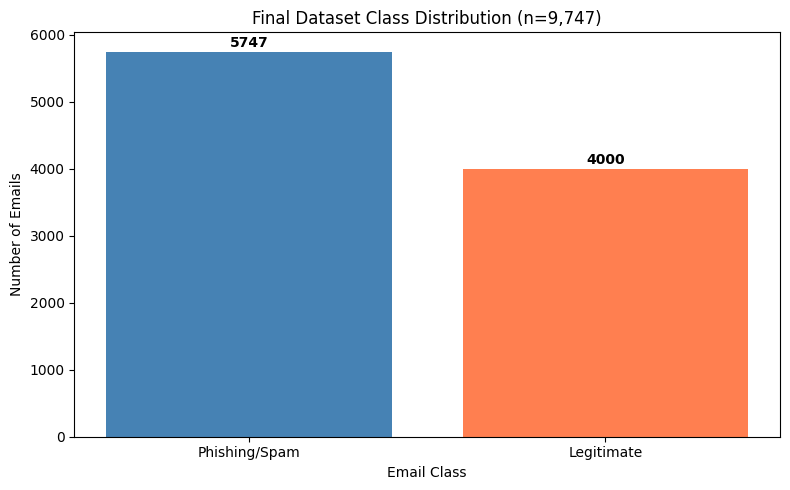

In [38]:
import matplotlib.pyplot as plt

label_counts = df_final['label'].value_counts()
label_names = {0: 'Legitimate', 1: 'Phishing/Spam'}

plt.figure(figsize=(8, 5))
bars = plt.bar(
    [label_names[i] for i in label_counts.index],
    label_counts.values,
    color=['steelblue', 'coral']
)
plt.xlabel('Email Class')
plt.ylabel('Number of Emails')
plt.title('Final Dataset Class Distribution (n=9,747)')
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

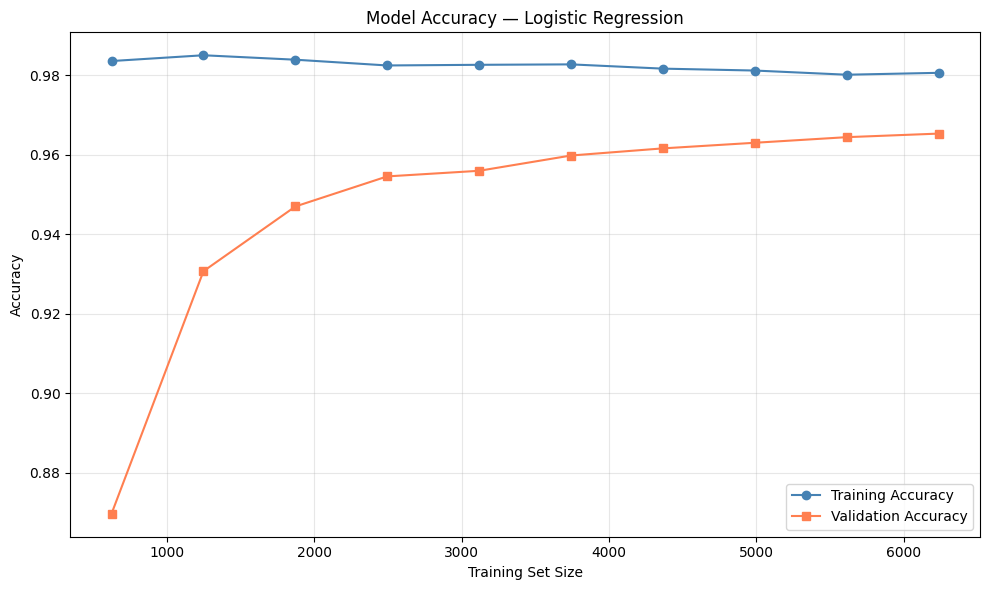

In [39]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Accuracy')
plt.plot(train_sizes, val_mean, 's-', color='coral', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Model Accuracy — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

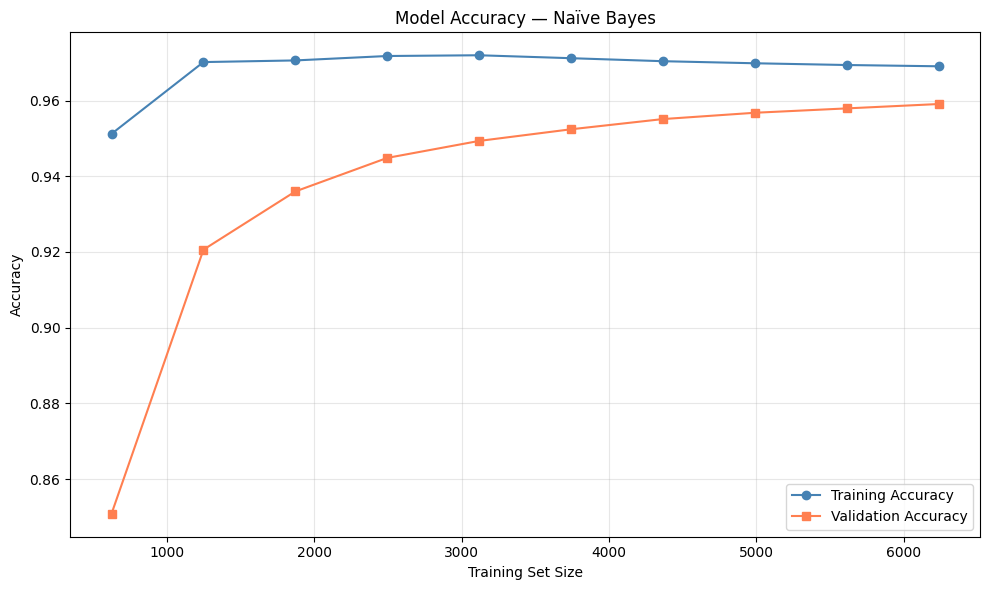

In [40]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes_nb, train_scores_nb, val_scores_nb = learning_curve(
    nb_model, X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean_nb = np.mean(train_scores_nb, axis=1)
val_mean_nb = np.mean(val_scores_nb, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_nb, train_mean_nb, 'o-', color='steelblue', label='Training Accuracy')
plt.plot(train_sizes_nb, val_mean_nb, 's-', color='coral', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Model Accuracy — Naïve Bayes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()